In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS, hl_sac

In [2]:
env_name = "Shooting"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [3]:
action_low = env.action_space.low[:4]
action_high = env.action_space.high[:4]
action_bounds = (action_low, action_high)

In [4]:
params = SB3_PARAMS
hidden_sizes = [128, 128]
params['alpha'] = 0.01
params['lr'] = 0.
# params["lr_critic"] = 1e-3

In [5]:
random_seed = 0

In [6]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [15]:
# sac = hl_sac(hidden_sizes=hidden_sizes, action_bounds=action_bounds, **params)
sac = from_dict(hidden_sizes=hidden_sizes, action_bounds=action_bounds, **params)

In [16]:
agent = sac
agent_name = "SACtest"

In [17]:
filepath = f"./defense/{agent_name}-{env_name}-{random_seed}"

In [18]:
# state = torch.load(f'{filepath}-{3639}.pth')
# agent.restore_state(state)

In [19]:
scaling = np.asarray([ 1.0,  1.0 , 0.5, 4.0, 4.0, 4.0,  
            1.0,  1.0,  0.5, 4.0, 4.0, 4.0,  
            2.0, 2.0, 10.0, 10.0, 4.0 ,4.0])

In [20]:
env_name = "Defense"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [21]:
for i in range(5):
    o, info = env.reset()
    # o /= scaling
    env.render()
    
    for _ in range(1000):
        env.render()
        a1 = agent.act(o, noise_scale=0.) # np.random.uniform(-1,1,4)
        # a1 = np.random.uniform(-1, 1, 4)
        a2 = [0,0.,0,0] 
        obs, r, d, t , info = env.step(np.hstack([a1,a2]))
        # obs /= scaling
        agent.store_transition((o, a1, r, obs, d))
        o = obs
        # obs_agent2 = env.obs_agent_two()
        if d or t: break

In [22]:
env.close()

In [23]:
losses = []
rewards = []
i_episode = 0
env_name = "Shooting"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [24]:
max_timesteps = 1000
new_episodes = 2000
log_interval = 10
train_interval = 10

In [25]:
for i in range(new_episodes):
    total_reward = 0
    o, info = env.reset()
    # o /= scaling
    # env.render()

    for j in range(max_timesteps):
        # env.render()
        a1 = agent.act(o) # np.random.uniform(-1,1,4)
        a2 = [0,0.,0,0] 
        obs, r, d, t , info = env.step(np.hstack([a1,a2]))
        # obs /= scaling
        agent.store_transition((o, a1, r, obs, d))
        if j % train_interval == 0:
            loss = agent.train()
            losses.append(loss)
        total_reward += r
        o = obs
        # obs_agent2 = env.obs_agent_two()
        if d or t: break

    i_episode += 1
    
    rewards.append(total_reward)
    if (i_episode+1) % log_interval == 0:
        print(i_episode+1, np.mean(rewards[-10:]))

10 -29.1187007515659
20 -24.51373649838318
30 -29.462965093896248
40 -29.25932102688676
50 -31.379760295750913
60 -36.69504770909815
70 -31.14114570177245
80 -28.893641674479248
90 -12.053444800795276
100 -24.399089785377384
110 -25.543800831765356
120 -28.06517884033144
130 -23.93087251447161
140 -23.94498192894504
150 -23.46153299843376
160 -19.020631499617117
170 -18.699059256395085
180 -4.314775106380402
190 -12.53934567487499
200 -3.033188935687207
210 -7.653949684580769
220 -12.55627394403246
230 -18.758403060684067
240 -15.788355375779807
250 -16.73156464201869
260 -10.753257295169819
270 -8.639725578966324
280 -13.85951323412218
290 -2.871615698221457
300 -10.487137044983891
310 -6.103840624981706
320 -7.75713794792822
330 -10.948483398326928
340 -12.714598695801934
350 -14.616954515323167
360 -5.259289249471909
370 -8.347815724870474
380 -7.986460442070299
390 -5.184083787747683
400 -7.2205422119799465
410 -2.019119657931589
420 -7.602065726564743
430 -8.214593857423566
440 -1

In [110]:
print("########## Saving a checkpoint... ##########")
torch.save(agent.state(), f'{filepath}-{i_episode}.pth')

########## Saving a checkpoint... ##########


In [111]:
from sac.utils import save_statistics
save_statistics(filepath, rewards, [], losses)

In [26]:
plot_path = "comp"

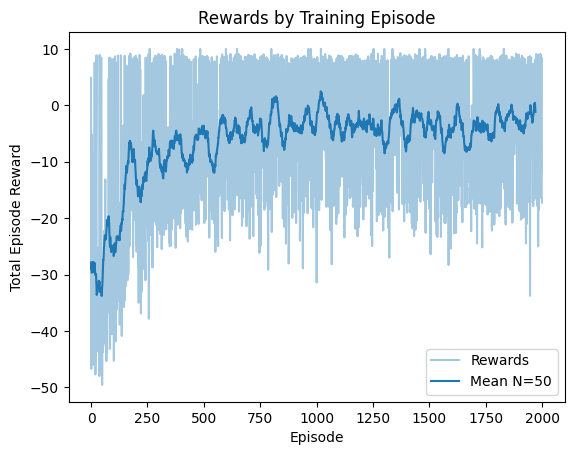

In [27]:
plot_rewards(rewards, plot_path, 30)

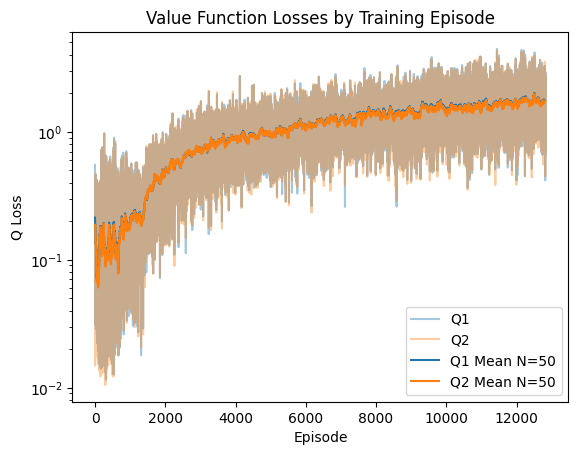

In [28]:
q_losses = np.asarray(losses)[:,:2]
plot_q(q_losses, plot_path)

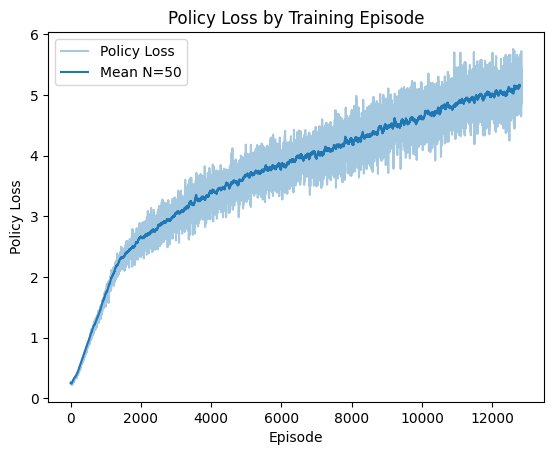

In [29]:
policy_loss = np.asarray(losses)[:,2]
plot_policy_loss(policy_loss, plot_path)

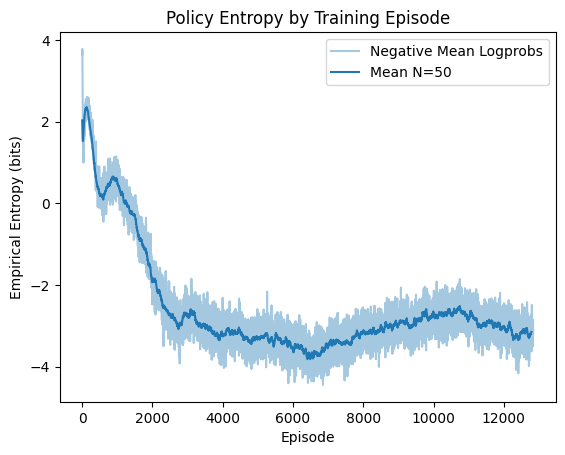

In [30]:
logprobs = np.asarray(losses)[:,-1]
plot_entropy(logprobs, plot_path)